# Assignment 8
## Submitted by Chaitanya Jindal

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats

df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


#### Dataset Overview

In [2]:
df.shape

(891, 15)

In [3]:
df.columns.tolist()

['survived',
 'pclass',
 'sex',
 'age',
 'sibsp',
 'parch',
 'fare',
 'embarked',
 'class',
 'who',
 'adult_male',
 'deck',
 'embark_town',
 'alive',
 'alone']

In [4]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


#### Missing Values and Data Types

In [6]:
summary_table = pd.DataFrame({
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2),
    "Type": df.dtypes.astype(str)
})

summary_table

,Unique Values,Missing Values,Missing %,Type
survived,2,0,0.00,int64
pclass,3,0,0.00,int64
sex,2,0,0.00,str
age,88,177,19.87,float64
sibsp,7,0,0.00,int64
parch,7,0,0.00,int64
fare,248,0,0.00,float64
embarked,3,2,0.22,str
class,3,0,0.00,category
who,3,0,0.00,str


In [8]:
summary_table.sort_values(by="Missing %", ascending=False).head(10)

,Unique Values,Missing Values,Missing %,Type
deck,7,688,77.22,category
age,88,177,19.87,float64
embarked,3,2,0.22,str
embark_town,3,2,0.22,str
sex,2,0,0.00,str
pclass,3,0,0.00,int64
survived,2,0,0.00,int64
fare,248,0,0.00,float64
parch,7,0,0.00,int64
sibsp,7,0,0.00,int64


#### Handling Missing Data

In [10]:
df_clean = df.copy()

df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
df_clean["embark_town"] = df_clean["embark_town"].fillna(df_clean["embark_town"].mode()[0])

df_clean = df_clean.drop(columns=["deck", "alive"])

df_clean.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alone          0
dtype: int64

#### Features that seem useful for prediction of survival...
- sex
- pclass
- age
- fare
- embarked
- embark_town
- alone
- sibsp
- parch

In [11]:
print("Survival rate by sex:")
print(df_clean.groupby("sex")["survived"].mean())

print("\nSurvival rate by pclass:")
print(df_clean.groupby("pclass")["survived"].mean())

print("\nSurvival rate by embarked:")
print(df_clean.groupby("embarked")["survived"].mean())

print("\nSurvival rate by embark_town:")
print(df_clean.groupby("embark_town")["survived"].mean())

print("\nSurvival rate by alone:")
print(df_clean.groupby("alone")["survived"].mean())

Survival rate by sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Survival rate by pclass:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Survival rate by embarked:
embarked
C    0.553571
Q    0.389610
S    0.339009
Name: survived, dtype: float64

Survival rate by embark_town:
embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.339009
Name: survived, dtype: float64

Survival rate by alone:
alone
False    0.505650
True     0.303538
Name: survived, dtype: float64


#### Univariate Visualization

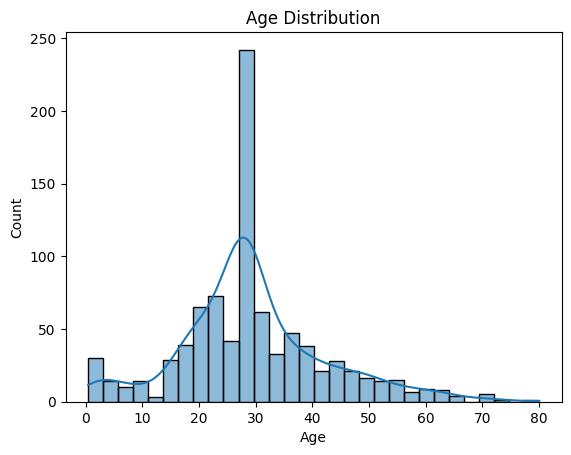

In [12]:
sns.histplot(df_clean["age"], kde=True)
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

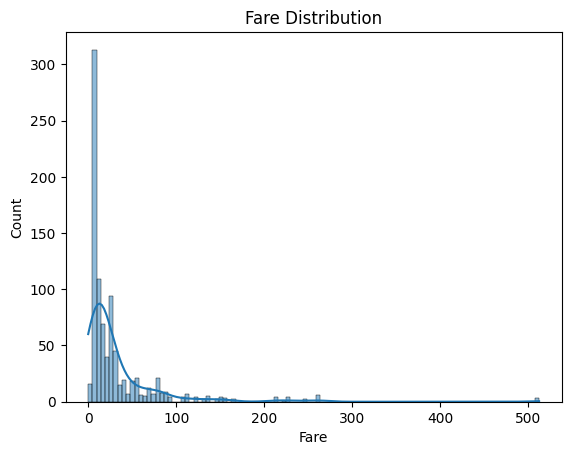

In [13]:
sns.histplot(df_clean["fare"], kde=True)
plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")
plt.show()

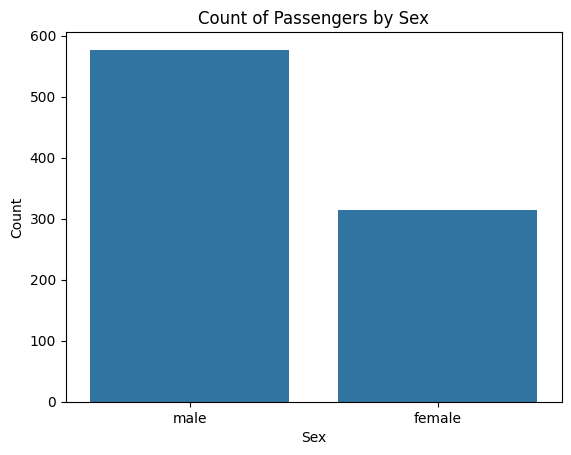

In [14]:
sns.countplot(x="sex", data=df_clean)
plt.title("Count of Passengers by Sex")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.show()

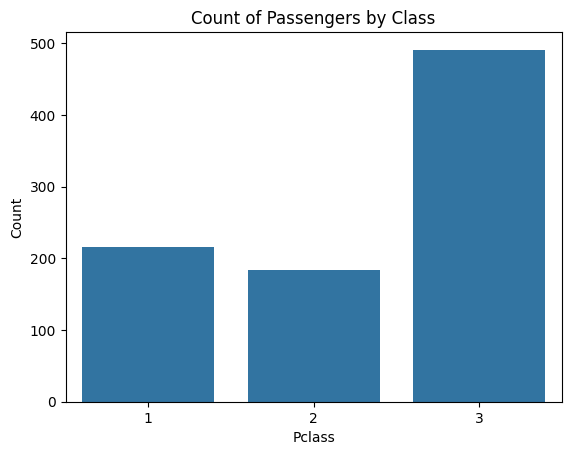

In [15]:
sns.countplot(x="pclass", data=df_clean)
plt.title("Count of Passengers by Class")
plt.xlabel("Pclass")
plt.ylabel("Count")
plt.show()

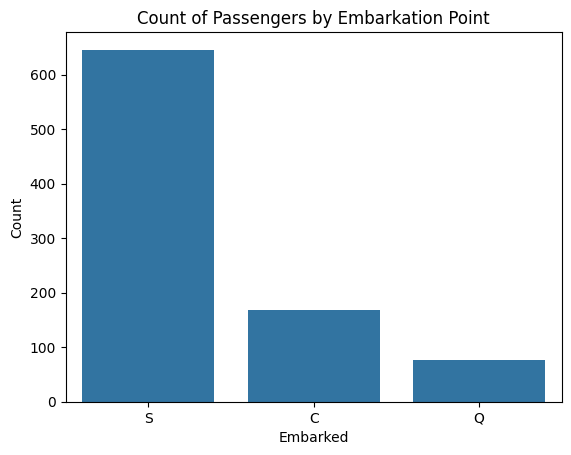

In [16]:
sns.countplot(x="embarked", data=df_clean)
plt.title("Count of Passengers by Embarkation Point")
plt.xlabel("Embarked")
plt.ylabel("Count")
plt.show()

#### Boxplots and Violinplots

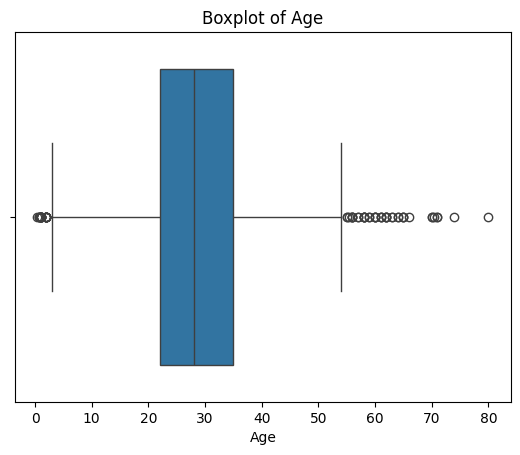

In [17]:
sns.boxplot(x=df_clean["age"])
plt.title("Boxplot of Age")
plt.xlabel("Age")
plt.show()

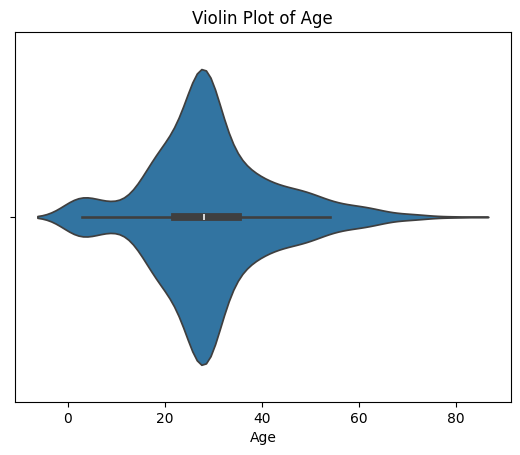

In [ ]:
sns.violinplot(x=df_clean["age"])
plt.title("Violin Plot of Age")
plt.xlabel("Age")
plt.show()

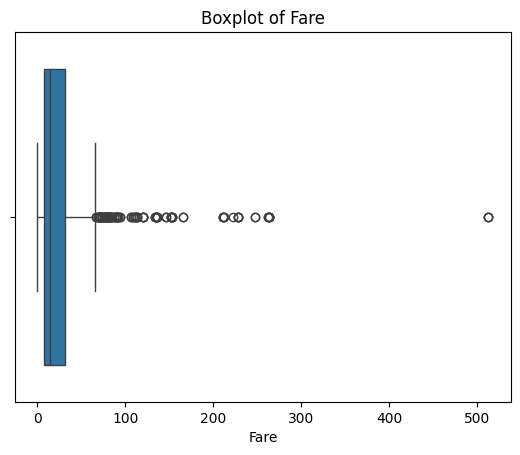

In [19]:
sns.boxplot(x=df_clean["fare"])
plt.title("Boxplot of Fare")
plt.xlabel("Fare")
plt.show()

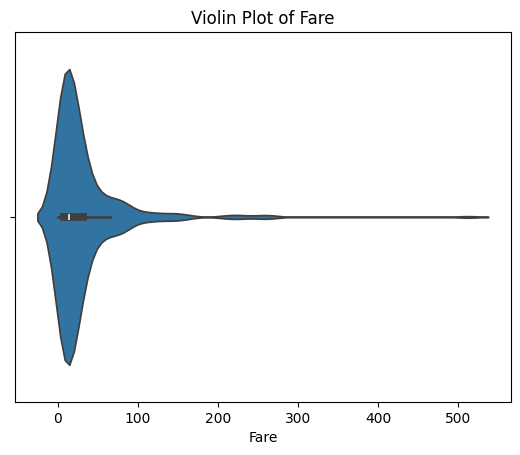

In [20]:
sns.violinplot(x=df_clean["fare"])
plt.title("Violin Plot of Fare")
plt.xlabel("Fare")
plt.show()

#### Which Age Group and Class Paid the Highest Fare?

In [21]:
age_bins = [0, 12, 18, 30, 45, 60, 80]
age_labels = ["Child", "Teen", "Young Adult", "Adult", "Middle Age", "Senior"]

df_clean["age_group"] = pd.cut(df_clean["age"], bins=age_bins, labels=age_labels, include_lowest=True)

fare_by_age_group = df_clean.groupby("age_group", observed=True)["fare"].mean().sort_values(ascending=False)
fare_by_class = df_clean.groupby("pclass")["fare"].mean().sort_values(ascending=False)

print("Average fare by age group:")
print(fare_by_age_group)

print("\nAverage fare by class:")
print(fare_by_class)

Average fare by age group:
age_group
Middle Age     45.332410
Senior         41.371214
Adult          41.265077
Teen           33.451313
Child          31.536352
Young Adult    25.187274
Name: fare, dtype: float64

Average fare by class:
pclass
1    84.154687
2    20.662183
3    13.675550
Name: fare, dtype: float64


#### Fare Distribution

In [22]:
print(f"Skewness of fare: {df_clean['fare'].skew():.2f}")
print(f"Skewness of age: {df_clean['age'].skew():.2f}")

Skewness of fare: 4.79
Skewness of age: 0.51


In [23]:
q1 = df_clean["fare"].quantile(0.25)
q3 = df_clean["fare"].quantile(0.75)
iqr = q3 - q1
lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

fare_outliers = df_clean[(df_clean["fare"] < lower) | (df_clean["fare"] > upper)]
print(f"Number of fare outliers: {fare_outliers.shape[0]}")

Number of fare outliers: 116


#### Bivariate Relationships

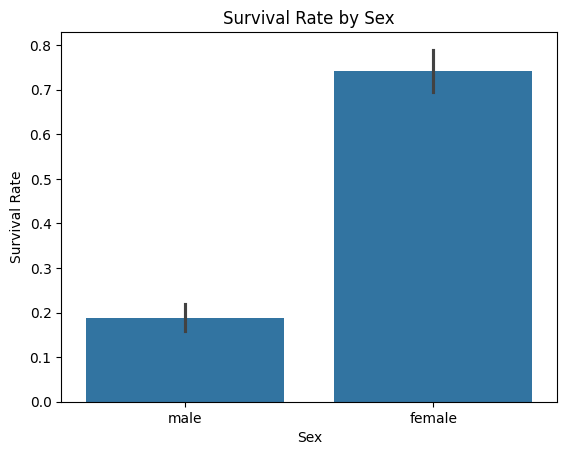

In [24]:
sns.barplot(x="sex", y="survived", data=df_clean)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.show()

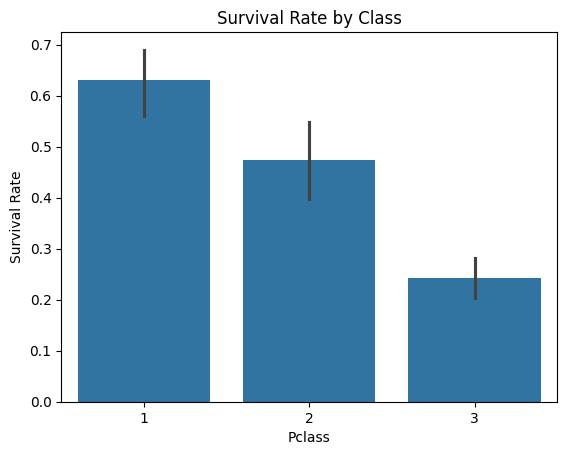

In [25]:
sns.barplot(x="pclass", y="survived", data=df_clean)
plt.title("Survival Rate by Class")
plt.xlabel("Pclass")
plt.ylabel("Survival Rate")
plt.show()

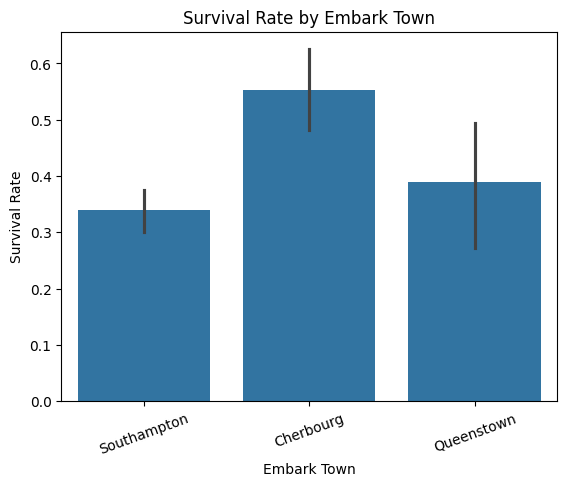

In [26]:
sns.barplot(x="embark_town", y="survived", data=df_clean)
plt.title("Survival Rate by Embark Town")
plt.xlabel("Embark Town")
plt.ylabel("Survival Rate")
plt.xticks(rotation=20)
plt.show()

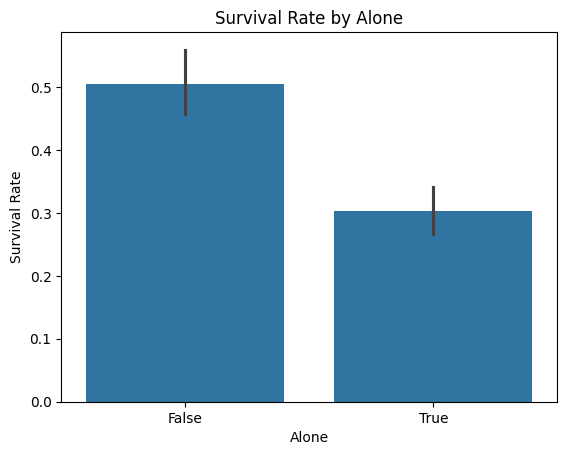

In [27]:
sns.barplot(x="alone", y="survived", data=df_clean)
plt.title("Survival Rate by Alone")
plt.xlabel("Alone")
plt.ylabel("Survival Rate")
plt.show()

#### Boxplots for Survival Comparison

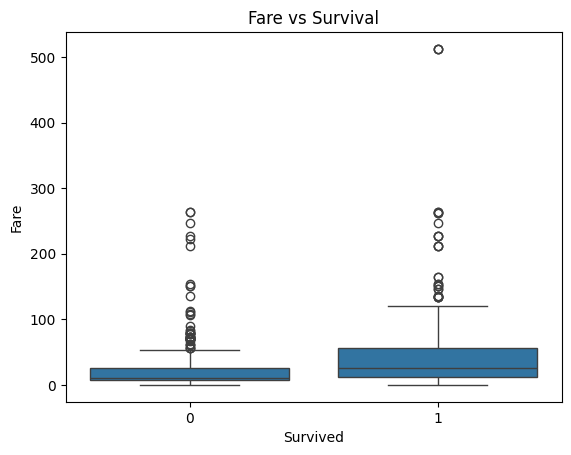

In [28]:
sns.boxplot(x="survived", y="fare", data=df_clean)
plt.title("Fare vs Survival")
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.show()

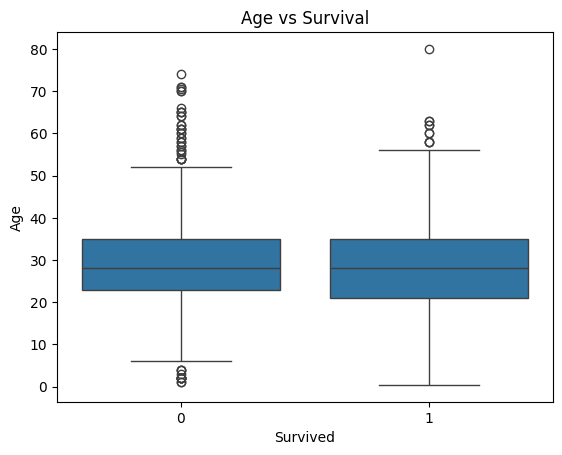

In [29]:
sns.boxplot(x="survived", y="age", data=df_clean)
plt.title("Age vs Survival")
plt.xlabel("Survived")
plt.ylabel("Age")
plt.show()

#### Scatterplots and Trend Check

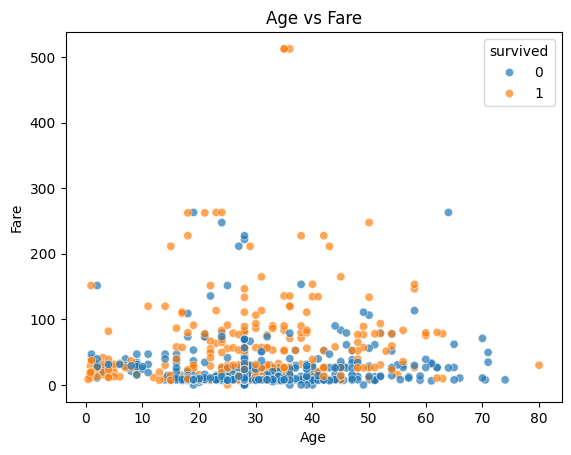

In [30]:
sns.scatterplot(x="age", y="fare", hue="survived", data=df_clean, alpha=0.7)
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

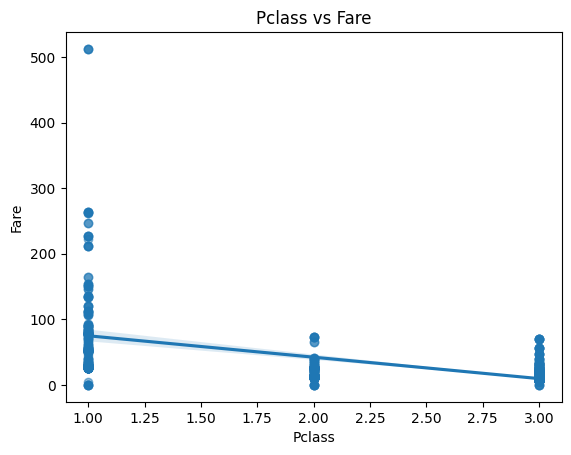

In [31]:
sns.regplot(x="pclass", y="fare", data=df_clean, scatter_kws={"alpha":0.5})
plt.title("Pclass vs Fare")
plt.xlabel("Pclass")
plt.ylabel("Fare")
plt.show()

#### Multi-Dimensional Visualization

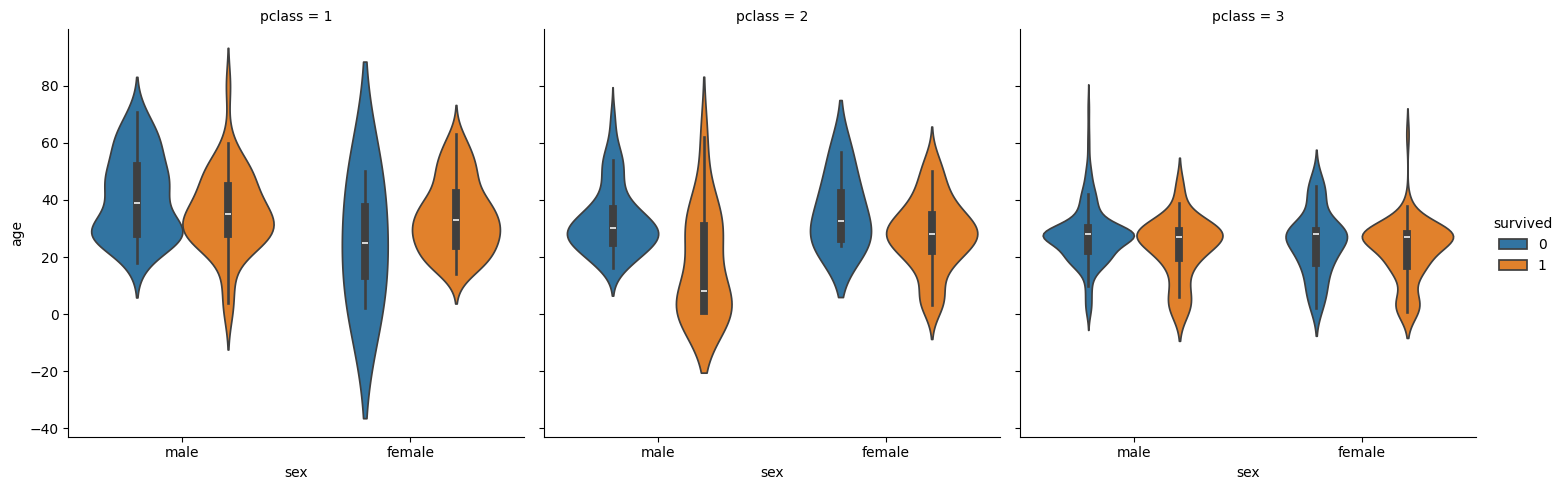

In [35]:
sns.catplot(
    x="sex",
    y="age",
    hue="survived",
    col="pclass",
    data=df_clean,
    kind="violin"
)
plt.show()

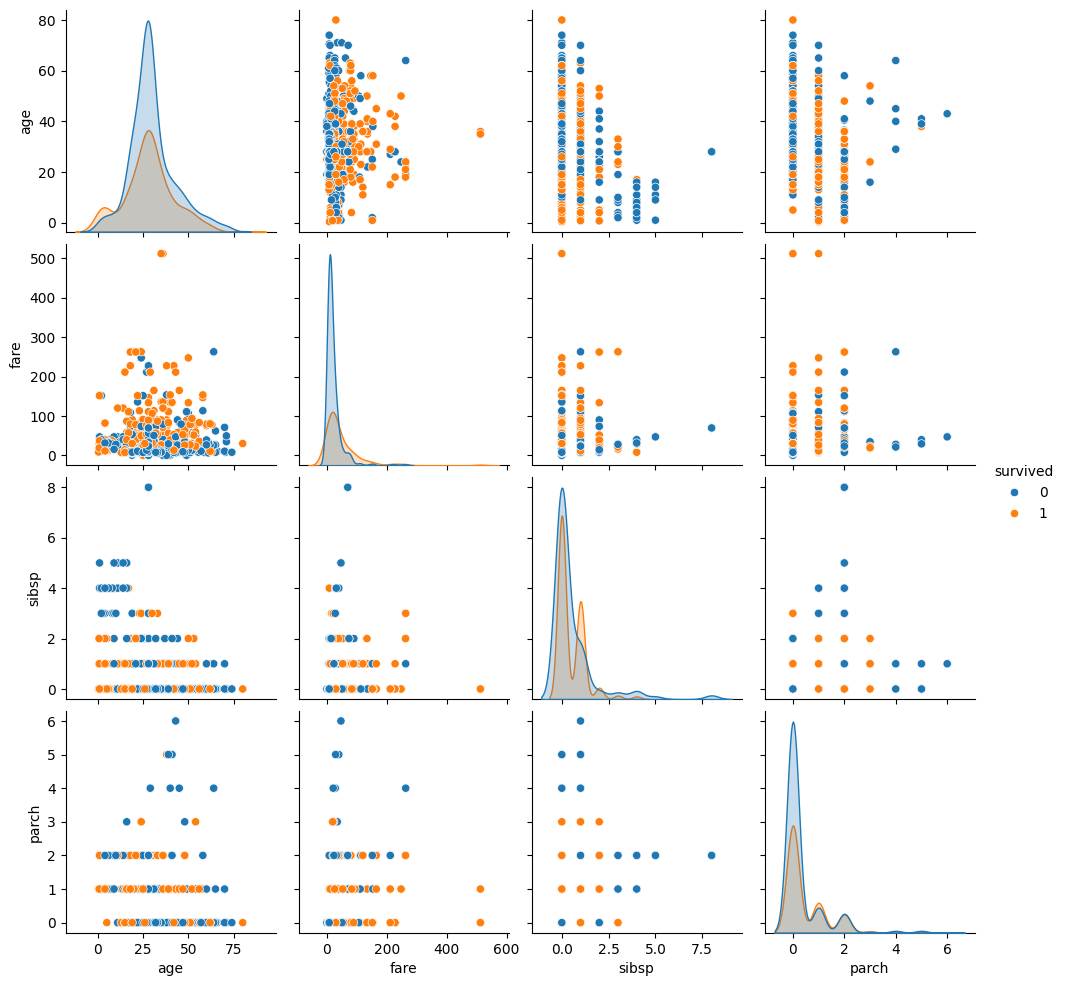

In [36]:
sns.pairplot(
    df_clean[["age", "fare", "sibsp", "parch", "survived"]].dropna(),
    hue="survived"
)
plt.show()

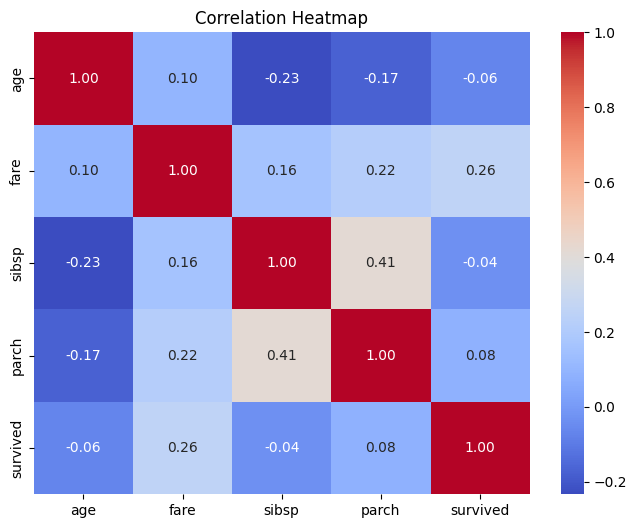

In [37]:
numeric_df = df_clean[["age", "fare", "sibsp", "parch", "survived"]]
corr_matrix = numeric_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

#### FacetGrid by Embarkation Point

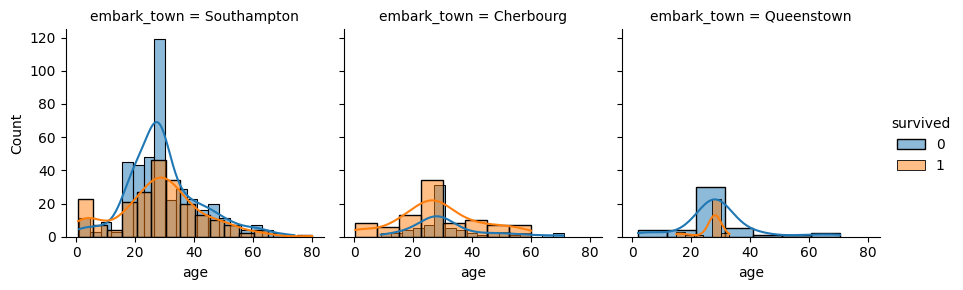

In [38]:
g = sns.FacetGrid(df_clean, col="embark_town", hue="survived")
g.map(sns.histplot, "age", kde=True, alpha=0.5)
g.add_legend()
plt.show()

#### Survival Chance with Age and Fare Together

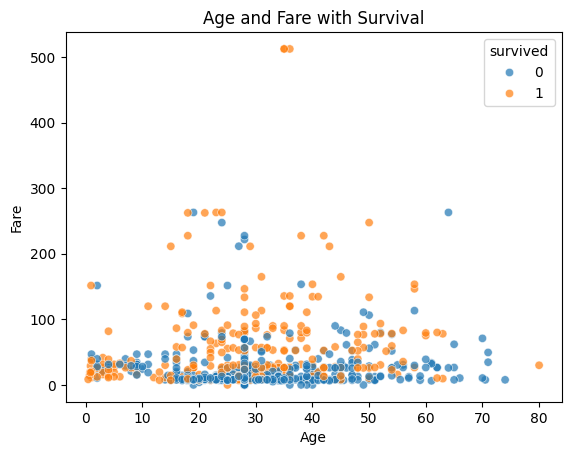

In [39]:
sns.scatterplot(x="age", y="fare", hue="survived", data=df_clean, alpha=0.7)
plt.title("Age and Fare with Survival")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()

#### Short Answers and Inference

In [40]:
print("Highest missing columns:")
print(summary_table.sort_values(by="Missing %", ascending=False).head())

print("\nMost useful features for survival prediction:")
print("sex, pclass, age, fare, embarked, embark_town, alone, sibsp, parch")

print("\nHighest survival rate by sex:")
print(df_clean.groupby("sex")["survived"].mean().sort_values(ascending=False))

print("\nHighest survival rate by pclass:")
print(df_clean.groupby("pclass")["survived"].mean().sort_values(ascending=False))

print("\nHighest survival rate by embark_town:")
print(df_clean.groupby("embark_town")["survived"].mean().sort_values(ascending=False))

Highest missing columns:
             Unique Values  Missing Values  Missing %      Type
deck                     7             688      77.22  category
age                     88             177      19.87   float64
embarked                 3               2       0.22       str
embark_town              3               2       0.22       str
sex                      2               0       0.00       str

Most useful features for survival prediction:
sex, pclass, age, fare, embarked, embark_town, alone, sibsp, parch

Highest survival rate by sex:
sex
female    0.742038
male      0.188908
Name: survived, dtype: float64

Highest survival rate by pclass:
pclass
1    0.629630
2    0.472826
3    0.242363
Name: survived, dtype: float64

Highest survival rate by embark_town:
embark_town
Cherbourg      0.553571
Queenstown     0.389610
Southampton    0.339009
Name: survived, dtype: float64


#### Final Observations

- The dataset has missing values mainly in cabin and deck related columns.
- Age was imputed with median.
- Embarked and embark_town were filled with mode.
- Fare is right-skewed.
- Fare has visible outliers.
- Women had higher survival probability than men.
- First-class passengers had the highest survival probability.
- Survival is related to class, sex, and fare.
- Age and fare do not show a strong linear relation.
- The sample is useful for Titanic analysis, but not for general population inference.

#### Answers

**Which columns have the highest missing values?**  
Cabin and deck have the highest missing values.

**Which features appear most promising for survival prediction?**  
Sex, pclass, age, fare, embarked, embark_town, alone, sibsp, and parch.

**Which age group and class paid the highest fares?**  
Higher fare is mostly seen in adults and first-class passengers.

**Is the fare distribution symmetric or skewed?**  
Fare is right-skewed.

**Which features show significant outliers?**  
Fare shows the strongest outliers.

**Which group had the highest survival probability?**  
Female passengers and first-class passengers.

**Is there a linear or nonlinear trend between age and fare?**  
There is no strong linear trend.

**Which embarkation point shows the highest survival rate?**  
It can be checked from the barplot on embark_town. Usually Cherbourg has a higher rate than others.

**Do survival chances vary with age and fare together?**  
Yes, passengers with higher fare generally had better survival chances.